In [10]:
# Basic import
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import sklearn

# Modelling
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import RandomizedSearchCV
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
import warnings
warnings.filterwarnings('ignore')

import dataset

In [17]:
df=pd.read_csv(r"D:\Data Science Krish Naik\MLproject4\logs\notebook\Data\stud.csv")

In [18]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


Preparing X and Y variables

In [22]:
x=df.drop(columns=['math_score'])

In [23]:
x.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,74
1,female,group C,some college,standard,completed,90,88
2,female,group B,master's degree,standard,none,95,93
3,male,group A,associate's degree,free/reduced,none,57,44
4,male,group C,some college,standard,none,78,75


In [24]:
y=df['math_score']

In [25]:
y

0      72
1      69
2      90
3      47
4      76
       ..
995    88
996    62
997    59
998    68
999    77
Name: math_score, Length: 1000, dtype: int64

In [26]:
#Create column transformer with 3 types of transformers
num_features=x.select_dtypes(exclude='object').columns
cat_features=x.select_dtypes(include='object').columns

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

numeric_transformer=StandardScaler()
oh_transformer=OneHotEncoder()

preprocessor=ColumnTransformer(
    [
        ("OneHotEncoder", oh_transformer,cat_features),
        ("StandardScaler", numeric_transformer, num_features),

    ]
)

In [27]:
x=preprocessor.fit_transform(x)

In [28]:
x

array([[ 1.        ,  0.        ,  0.        , ...,  1.        ,
         0.19399858,  0.39149181],
       [ 1.        ,  0.        ,  0.        , ...,  0.        ,
         1.42747598,  1.31326868],
       [ 1.        ,  0.        ,  0.        , ...,  1.        ,
         1.77010859,  1.64247471],
       ...,
       [ 1.        ,  0.        ,  0.        , ...,  0.        ,
         0.12547206, -0.20107904],
       [ 1.        ,  0.        ,  0.        , ...,  0.        ,
         0.60515772,  0.58901542],
       [ 1.        ,  0.        ,  0.        , ...,  1.        ,
         1.15336989,  1.18158627]], shape=(1000, 19))

In [29]:
x.shape

(1000, 19)

In [30]:
# separate dataset into train and test
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
x_train.shape,x_test.shape

((800, 19), (200, 19))

Create and evaluate function to give all metrics after model training

In [31]:
def evaluate_model(true, predicted):
    mae=mean_absolute_error(true, predicted)
    mse=mean_squared_error(true, predicted)
    rmse=np.sqrt(mean_squared_error(true, predicted))
    r2_square=r2_score(true, predicted)
    return mae,rmse,r2_square

In [32]:
models={
    "Linear Regression": LinearRegression(),
    "Lasso": Lasso(),
    "Ridge": Ridge(),
    "K-Neighbors Regressor": KNeighborsRegressor(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest Regressor": RandomForestRegressor(),
    "XGBRegressor": XGBRegressor(),
    "CatBoosting Regressor": CatBoostRegressor(verbose=False),
    "AdaBoost Regressor": AdaBoostRegressor()
}
model_list=[]
r2_list=[]

for i in range(len(list(models))):
    model=list(models.values())[i]
    model.fit(x_train,y_train) #Train model

    #Make predictions
    y_train_pred=model.predict(x_train)
    y_test_pred=model.predict(x_test)

    # Evaluate train and test dataset
    model_train_mae, model_train_rmse, model_train_r2=evaluate_model(y_train,y_train_pred)
    model_test_mae, model_test_rmse, model_test_r2=evaluate_model(y_test,y_test_pred)

    print(list(models.keys())[i])
    model_list.append(list(models.keys())[i])

    print('Model performance for training set')
    print("- Root Mean Squared Error: {:4f}".format(model_train_rmse))
    print("- Mean Absolute Error: {:4f}".format(model_train_mae))
    print("- R2 Score: {:4f}".format(model_train_r2))

    print('----------------------------')

    print('Model performance for test set')
    print("- Root Mean Squared Error: {:4f}".format(model_test_rmse))
    print("- Mean Absolute Error: {:4f}".format(model_test_mae))
    print("- R2 Score: {:4f}".format(model_test_r2))
    r2_list.append(model_test_r2)

    print('='*35)
    print('\n')

Linear Regression
Model performance for training set
- Root Mean Squared Error: 5.323051
- Mean Absolute Error: 4.266712
- R2 Score: 0.874317
----------------------------
Model performance for test set
- Root Mean Squared Error: 5.393994
- Mean Absolute Error: 4.214763
- R2 Score: 0.880433


Lasso
Model performance for training set
- Root Mean Squared Error: 6.593816
- Mean Absolute Error: 5.206303
- R2 Score: 0.807146
----------------------------
Model performance for test set
- Root Mean Squared Error: 6.519695
- Mean Absolute Error: 5.157882
- R2 Score: 0.825320


Ridge
Model performance for training set
- Root Mean Squared Error: 5.323325
- Mean Absolute Error: 4.264988
- R2 Score: 0.874304
----------------------------
Model performance for test set
- Root Mean Squared Error: 5.390387
- Mean Absolute Error: 4.211101
- R2 Score: 0.880593


K-Neighbors Regressor
Model performance for training set
- Root Mean Squared Error: 5.707885
- Mean Absolute Error: 4.516750
- R2 Score: 0.855488

Performance selection

In [33]:
pd.DataFrame(list(zip(model_list,r2_list)), columns=['Model Name', 'R2_Score']).sort_values(by=["R2_Score"],ascending=False)

,Model Name,R2_Score
2,Ridge,0.880593
0,Linear Regression,0.880433
7,CatBoosting Regressor,0.851632
5,Random Forest Regressor,0.850480
8,AdaBoost Regressor,0.846074
6,XGBRegressor,0.827797
1,Lasso,0.825320
3,K-Neighbors Regressor,0.783813
4,Decision Tree,0.733252


Linear Regression Chosen

In [34]:
lin_model=LinearRegression(fit_intercept=True)
lin_model=lin_model.fit(x_train,y_train)
y_pred=lin_model.predict(x_test)
score=r2_score(y_test, y_pred)*100
print("Accuracy of the model is %.2f" %score)

Accuracy of the model is 88.04


Plot y_pred and y_test

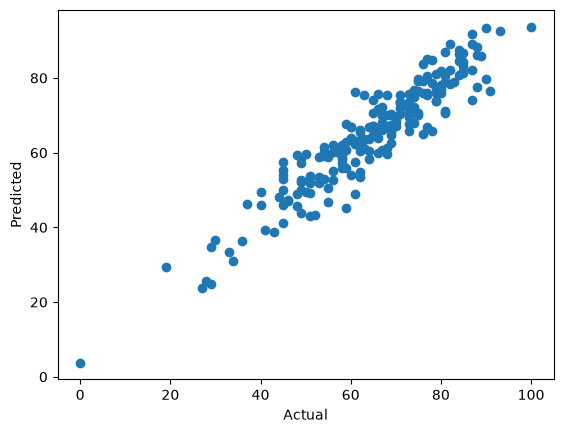

In [35]:
plt.scatter(y_test,y_pred);
plt.xlabel('Actual');
plt.ylabel('Predicted');

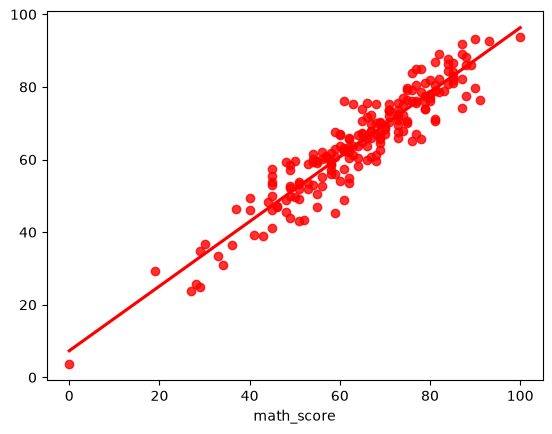

In [36]:
sns.regplot(x=y_test,y=y_pred,ci=None,color='red');

Difference between Actual and Predicted Values

In [37]:
pred_df=pd.DataFrame({'Actual Value':y_test,'Predicted Value':y_pred,'Difference':y_test-y_pred})

In [38]:
pred_df

,Actual Value,Predicted Value,Difference
521,91,76.387970,14.612030
737,53,58.885970,-5.885970
740,80,76.990265,3.009735
660,74,76.851804,-2.851804
411,84,87.627378,-3.627378
...,...,...,...
408,52,43.409149,8.590851
332,62,62.152214,-0.152214
208,74,67.888395,6.111605
613,65,67.022287,-2.022287


In [9]:
%pip install catboost xgboost

  Using cached graphviz-0.21-py3-none-any.whl.metadata (12 kB)
   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/100.2 MB ? eta -:--:--
   ---------------------------------------- 1.0/100.2 MB 2.3 MB/s eta 0:00:44
    --------------------------------------- 1.3/100.2 MB 2.3 MB/s eta 0:00:43
    --------------------------------------- 1.8/100.2 MB 2.2 MB/s eta 0:00:45
    --------------------------------------- 2.1/100.2 MB 2.0 MB/s eta 0:00:49
    --------------------------------------- 2.4/100.2 MB 1.9 MB/s eta 0:00:52
   - -------------------------------------- 2.9/100.2 MB 1.9 MB/s eta 0:00:51
   - -------------------------------------- 3.1/100.2 MB 1.8 MB/s eta 0:00:54
   - -------------------------------------- 3.1/100.2 MB 1.8 MB/s eta 0:00:54
   - -------------------------------------- 3.4/100.2 MB 1.7 MB/s eta 0:00:57
   - -----------------

Import dataset

In [7]:
%pip install scikit-learn

   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.3 MB ? eta -:--:--
   ------ --------------------------------- 1.3/8.3 MB 5.2 MB/s eta 0:00:02
   ------ --------------------------------- 1.3/8.3 MB 5.2 MB/s eta 0:00:02
   ------------- -------------------------- 2.9/8.3 MB 4.0 MB/s eta 0:00:02
   ------------------- -------------------- 3.9/8.3 MB 4.0 MB/s eta 0:00:02
   ------------------- -------------------- 3.9/8.3 MB 4.0 MB/s eta 0:00:02
   ------------------------- -------------- 5.2/8.3 MB 3.9 MB/s eta 0:00:01
   ----------------------------- ---------- 6.0/8.3 MB 3.8 MB/s eta 0:00:01
   ------------------------------- -------- 6.6/8.3 MB 3.7 MB/s eta 0:00:01
   ---------------------------------- ----- 7.1/8.3 MB 3.6 MB/s eta 0:00:01
   ------------------------------------ --- 7.6/8.3 MB 3.4 MB/s eta 0:00:01
   ---------------------------------------  8.1/8.3 MB 3.4 MB/s eta 0:00:01
   -----------------------